# WGAN Test Code: Gaussian Mixture Model

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.autograd import Variable
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
import random

These hyperparameters are from the WGAN reference. The clipping parameter was slightly increased to allow for larger range for parameter estimates. This has yielded more stable performance, but this may also be due to the very simple NN architecture used here.

In [2]:
# Hyperparameters based on reference paper
lr = 5e-5
c = 0.015
# Batchsize also increased to 128 from reference
batch_size = 128
n_critic = 5
# 1D latent variable
z_dim = 1 
num_epochs = 5000

Text(0.5, 1.0, 'Target Gaussian Mixture Distribution')

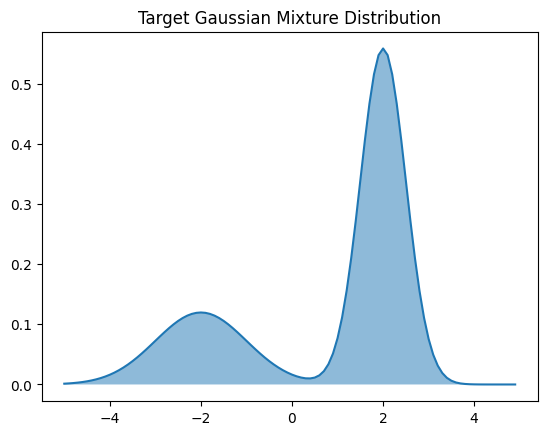

In [3]:
# Plot true distribution
def true_samps(x):
    return 0.7*sp.stats.norm.pdf(x,2,0.5) + 0.3*sp.stats.norm.pdf(x,-2,1)
x = np.arange(-5,5,0.1)
y = true_samps(x)
plt.plot(x,y)
plt.fill_between(x, y, alpha=0.5)
plt.title("Target Gaussian Mixture Distribution")

In [4]:
# Sample from Real Data Distribution
def sample_real_data(batch_size):
    component = torch.bernoulli(0.7 * torch.ones(batch_size,1))  # 70% chance for mean 2 Gaussian
    data = component * torch.normal(2, 0.5, size=(batch_size, 1)) + (1 - component) * torch.normal(-2, 1, size=(batch_size, 1))
    return data

In [5]:
# Generator model, 2 hidden layer MLP w 64 nodes each
class Generator(nn.Module):
    def __init__(self, z_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(z_dim, 64),
            nn.LeakyReLU(0.2), # use LeakyReLU to protect from vanishing gradient
            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, z):
        return self.model(z)

In [6]:
# Discriminator model, 2 hidden layer MLP w 64 nodes each
class Critic(nn.Module):
    def __init__(self):
        super(Critic, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(1, 64),
            nn.LeakyReLU(0.2), 
            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.model(x)

In [7]:
def w_loss(D_real, D_fake):
    return (D_fake.mean() - D_real.mean())

In [8]:
# Jensen shannon loss does not learn
def js_loss(D_real, D_fake):
    p = nn.functional.softmax(D_fake, dim=0)
    q = nn.functional.softmax(D_real, dim=0)
    # Calculate the average distribution
    m = 0.5 * (p + q)
    
    # Calculate the JS divergence
    js_div = -0.5*(nn.functional.kl_div(p.log(), m, reduction='batchmean') + 
                    nn.functional.kl_div(q.log(), m, reduction='batchmean'))
    return js_div

In [9]:
def train_wgan(z_dim, num_epochs, batch_size, 
               clip=0.015, n_critic=5, lr=5e-5, loss_fct = w_loss,
               store_samples=True, store_loss=True, 
               early_stopping=False, seed=1):
    # Set seed for reproducibility... lots of libraries used
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    #  Initialize generator and critic
    G = Generator(z_dim)
    D = Critic()
    # Optimizers (RMSprop used in reference paper, adaptive stepsize)
    optimizer_G = optim.RMSprop(G.parameters(), lr=lr)
    optimizer_D = optim.RMSprop(D.parameters(), lr=lr)
    # store a few samples during training to see how the network is learning
    generated_samples = {}
    # list to store generator/discriminator loss at each epoch
    discriminator_losses = []
    generator_losses = []
    # Training loop
    for epoch in range(num_epochs):
        # Train discriminator
        for _ in range(n_critic):
            # Train Critic
            D.zero_grad()
            # Real data
            real_data = sample_real_data(batch_size).view(batch_size, 1) 
            # Fake data
            z = torch.randn(batch_size, z_dim)  # N(0, 1)
            fake_data = G(z).detach().view(batch_size, 1)  # Detach to avoid gradients flowing into generator
            # Critic loss
            D_real = D(real_data)
            D_fake = D(fake_data)
            D_loss = loss_fct(D_real, D_fake)
            # Compute gradient via backprop
            D_loss.backward()
            optimizer_D.step()
            # Weight clipping
            for p in D.parameters():
                p.data.clamp_(-clip, clip)
            if store_loss:
                discriminator_losses.append(D_loss.item())
        # Train Generator
        G.zero_grad()
        # Generate fake data
        z = torch.randn(batch_size, z_dim)
        fake_data = G(z)
        # Generator loss, i.e. maximize discriminator loss
        G_loss = -D(fake_data).mean()
        G_loss.backward()
        optimizer_G.step()
        # store loss
        if store_loss:
            generator_losses.append(G_loss.item())
        # Print losses for monitoring
        if epoch % 500 == 0:
            print(f"Epoch [{epoch}/{num_epochs}]  D_loss: {D_loss.item():.4f}  G_loss: {G_loss.item():.4f}")
        # see how the WGAN learns
        if store_samples and epoch in [int(np.floor(num_epochs/4))-1, 
                                       int(np.floor(num_epochs/2))-1, 
                                       3*int(np.floor(num_epochs/4))-1, 
                                       num_epochs-1]:
            see = torch.randn(1000, z_dim)
            generated_samples[epoch+1] = G(see).detach().numpy()
    return G,D, generated_samples, {"G":generator_losses,"D":discriminator_losses}

In [10]:
G_w,D_w, samples_w, losses_w =  train_wgan(z_dim=1, num_epochs=5000, batch_size=128, 
                                     clip=0.015, n_critic=5, lr=5e-5)

Epoch [0/5000]  D_loss: 0.0000  G_loss: 0.0142
Epoch [500/5000]  D_loss: -0.0023  G_loss: 0.0163
Epoch [1000/5000]  D_loss: -0.0005  G_loss: 0.0093
Epoch [1500/5000]  D_loss: -0.0002  G_loss: 0.0122
Epoch [2000/5000]  D_loss: -0.0001  G_loss: 0.0106
Epoch [2500/5000]  D_loss: -0.0001  G_loss: 0.0103
Epoch [3000/5000]  D_loss: -0.0000  G_loss: 0.0100
Epoch [3500/5000]  D_loss: -0.0000  G_loss: 0.0110
Epoch [4000/5000]  D_loss: -0.0000  G_loss: 0.0105
Epoch [4500/5000]  D_loss: 0.0001  G_loss: 0.0110


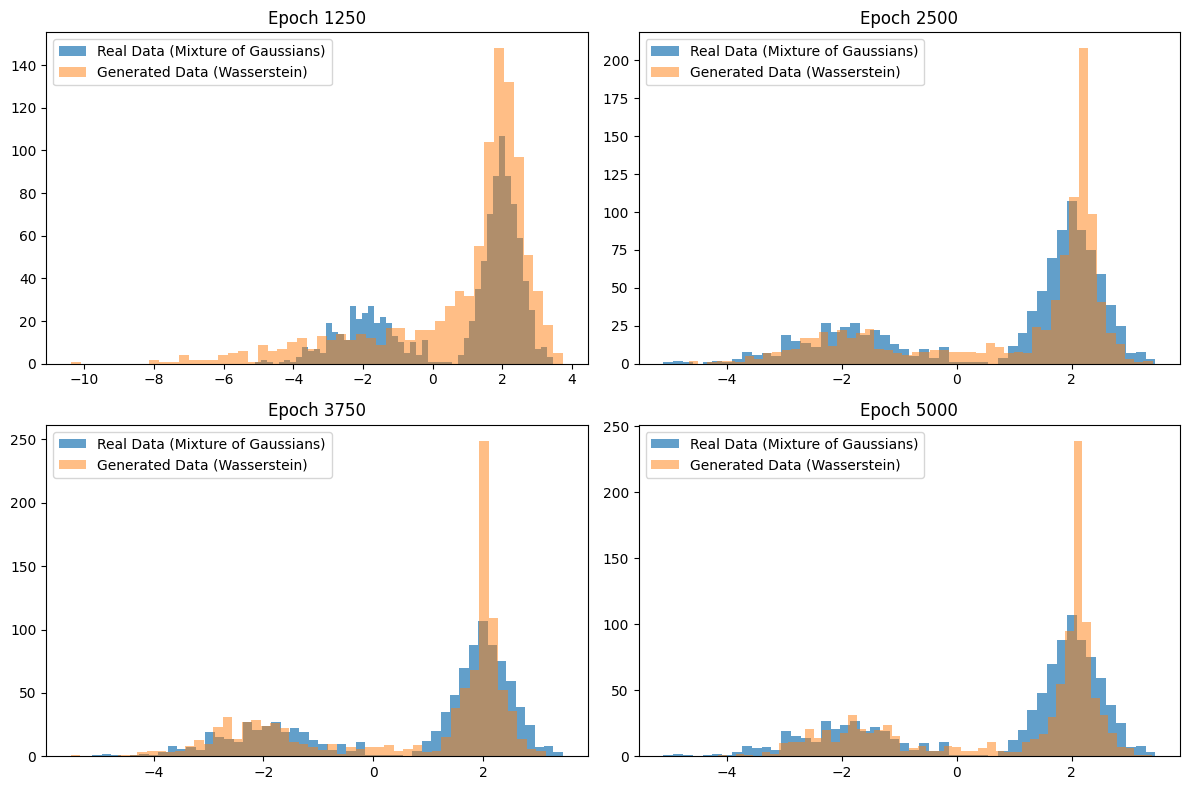

In [11]:
# Generate real samples for reference
real_samples = sample_real_data(1000).numpy()
# Set up subplot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
# list of sampled epochs (1/4 intervals of num_epochs)
epochs = [int(np.floor(num_epochs/4))-1, 
             int(np.floor(num_epochs/2))-1, 
          3*int(np.floor(num_epochs/4))-1, 
          num_epochs-1]
titles = [f'Epoch {epoch+1}' for epoch in epochs]
# Plot each panel
for i, ax in enumerate(axes.flatten()):
    epoch = epochs[i]
    fake_samples_w = samples_w[epoch+1]
    #fake_samples_js = samples_js[epoch+1]
    ax.hist(real_samples, bins=50, alpha=0.7, 
            label="Real Data (Mixture of Gaussians)")
    ax.hist(fake_samples_w, bins=50, alpha=0.5, 
            label="Generated Data (Wasserstein)")
    ax.set_title(titles[i])
    ax.legend()
plt.tight_layout()
plt.show()

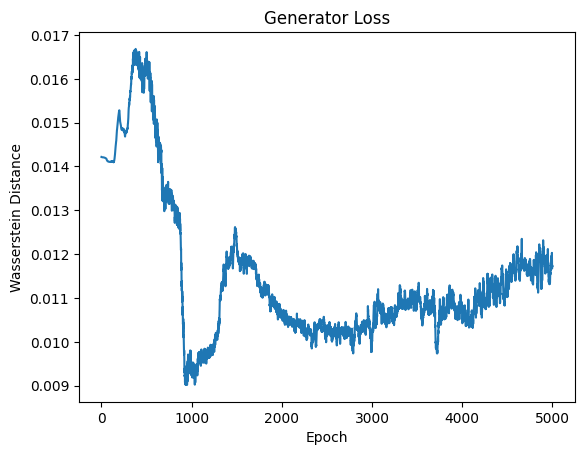

In [12]:
plt.plot(np.arange(0,5000), losses_w["G"], label="Wasserstein")
plt.title("Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Wasserstein Distance")
plt.show()